In [3]:
import cv2, time, sys, os, pathlib, json
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def angle_between_points(p1, p2, p3):
    a = np.array(p1)
    b = np.array(p2)
    c = np.array(p3)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.arccos(cosine_angle)

    return np.degrees(angle)

In [5]:
try:
    with open('test.json', 'r') as file:
        data = json.load(file)
    print("File data =", data)
    
except FileNotFoundError:
    print("Error: The file 'test.json' was not found.")

File data = {'athlete': 'ATH01', 'session': 's1', 'video': 'Pre Cut03.2103582.20240108160826.avi', 'frame_count': 598, 'frames': [{'frame': 0, 'landmarks': []}, {'frame': 1, 'landmarks': [{'index': 11, 'name': 'LEFT_SHOULDER', 'x': 0.11706622689962387, 'y': -0.4616546630859375, 'z': 0.03729555010795593, 'visibility': 0.9994282126426697}, {'index': 12, 'name': 'RIGHT_SHOULDER', 'x': -0.1394786685705185, 'y': -0.44766372442245483, 'z': 0.1109730452299118, 'visibility': 0.9898667335510254}, {'index': 23, 'name': 'LEFT_HIP', 'x': 0.09292369335889816, 'y': 0.0009170409757643938, 'z': -0.010153437033295631, 'visibility': 0.9973864555358887}, {'index': 24, 'name': 'RIGHT_HIP', 'x': -0.09292730689048767, 'y': -0.0013195829233154655, 'z': 0.011377266608178616, 'visibility': 0.9880036115646362}, {'index': 25, 'name': 'LEFT_KNEE', 'x': 0.06862355023622513, 'y': 0.3851394057273865, 'z': -0.07585997879505157, 'visibility': 0.9287341833114624}, {'index': 26, 'name': 'RIGHT_KNEE', 'x': -0.06831783056

There is 17 frames with no landmarks in them. [{'frame': 0, 'landmarks': []}, {'frame': 2, 'landmarks': []}, {'frame': 9, 'landmarks': []}, {'frame': 21, 'landmarks': []}, {'frame': 22, 'landmarks': []}, {'frame': 31, 'landmarks': []}, {'frame': 34, 'landmarks': []}, {'frame': 35, 'landmarks': []}, {'frame': 38, 'landmarks': []}, {'frame': 43, 'landmarks': []}, {'frame': 46, 'landmarks': []}, {'frame': 49, 'landmarks': []}, {'frame': 50, 'landmarks': []}, {'frame': 51, 'landmarks': []}, {'frame': 52, 'landmarks': []}, {'frame': 54, 'landmarks': []}, {'frame': 55, 'landmarks': []}]


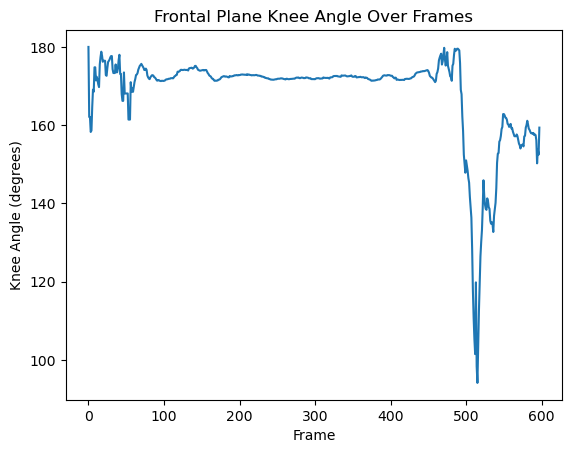

In [6]:
# Get a list with all the frames 
frames_list = list(data.items())[4][1]
angle_list = []
old_angle = 180
unmarked_frames = []
for frame in frames_list:
    if not frame['landmarks']:
        unmarked_frames.append(frame)
        p1, p2, p3 = None, None, None
        angle_list.append(old_angle)
        continue
    else:
        left_hip = [a for a in frame['landmarks'] if a['name'] == 'LEFT_HIP']
        left_knee = [a for a in frame['landmarks'] if a['name'] == 'LEFT_KNEE']
        left_ankle = [a for a in frame['landmarks'] if a['name'] == 'LEFT_ANKLE']
        p1 = [left_hip[0]['x'], left_hip[0]['y']]
        p2 = [left_knee[0]['x'], left_knee[0]['y']]
        p3 = [left_ankle[0]['x'], left_ankle[0]['y']]
        if left_hip is None or left_knee is None or left_ankle is None:
            print("Error: One of the points is None for frame", frame['frame'])
            break 
        angle = angle_between_points(p1, p2, p3)
        angle_list.append(angle)
        old_angle = angle

print(f"There is {len(unmarked_frames)} frames with no landmarks in them.", unmarked_frames)
# Plot the angle over frames
plt.plot(angle_list)
plt.xlabel('Frame')
plt.ylabel('Knee Angle (degrees)')
plt.title('Frontal Plane Knee Angle Over Frames')
plt.show()

In [7]:
def orientation_angle(left_hip, right_hip):
    angle = np.arccos((left_hip[0]['x'] - right_hip[0]['x']) / np.sqrt((left_hip[0]['x'] - right_hip[0]['x'])**2 + (left_hip[0]['z'] - right_hip[0]['z'])**2))
    return np.degrees(angle)

There is 17 frames with no landmarks in them. [0, 2, 9, 21, 22, 31, 34, 35, 38, 43, 46, 49, 50, 51, 52, 54, 55]


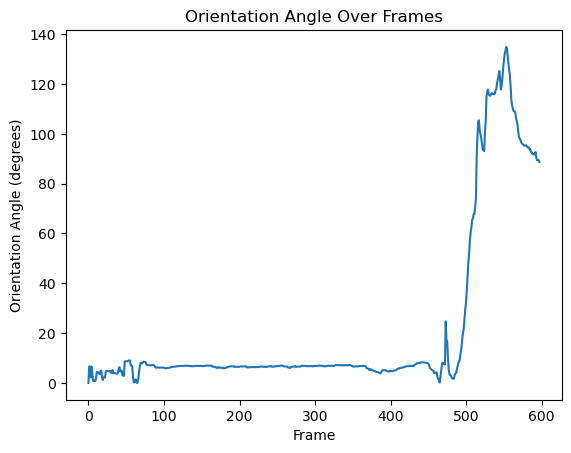

In [8]:
frames_list = list(data.items())[4][1]
orientation_list = []
old_angle = 0
unmarked_frames = []
for frame in frames_list:
    if not frame['landmarks']:
        unmarked_frames.append(frame['frame'])        
        p1, p2, p3 = None, None, None
        orientation_list.append(old_angle)
        continue
    else:
        left_hip = [a for a in frame['landmarks'] if a['name'] == 'LEFT_HIP']
        right_hip = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_HIP']
        if left_hip is None or right_hip is None:
            print("Error: No hip point found for frame", frame['frame'])
            break 
        angle = orientation_angle(left_hip, right_hip)
        orientation_list.append(angle)
        old_angle = angle

print(f"There is {len(unmarked_frames)} frames with no landmarks in them.", unmarked_frames)
# Plot the angle over frames
plt.plot(orientation_list)
plt.xlabel('Frame')
plt.ylabel('Orientation Angle (degrees)')
plt.title('Orientation Angle Over Frames')
plt.show()

In [9]:
unmarked_frames

[0, 2, 9, 21, 22, 31, 34, 35, 38, 43, 46, 49, 50, 51, 52, 54, 55]

# Computing the frontal plane from 3 landmarks (left hip, right hip, midpoint of hips and shoulders)

In [10]:
# This computes the normalized frontal plane normal vector using the hip and shoulder landmarks.
# It calculates the mid-point of the hips and shoulders, then creates two vectors from 
# the left hip to the mid-point and from the right hip to the mid-point.

def frontal_plane_normal_vector(left_hip, right_hip, left_shoulder, right_shoulder):
    mid_point = [(left_hip[0]['x'] + right_hip[0]['x'] + left_shoulder[0]['x'] + right_shoulder[0]['x']) / 4, 
                 (left_hip[0]['y'] + right_hip[0]['y'] + left_shoulder[0]['y'] + right_shoulder[0]['y']) / 4, 
                 (left_hip[0]['z'] + right_hip[0]['z'] + left_shoulder[0]['z'] + right_shoulder[0]['z']) / 4]
    v1 = [left_hip[0]['x'] - mid_point[0], left_hip[0]['y'] - mid_point[1], left_hip[0]['z'] - mid_point[2]]
    v2 = [right_hip[0]['x'] - mid_point[0], right_hip[0]['y'] - mid_point[1], right_hip[0]['z'] - mid_point[2]]
    normal_vector = np.cross(v1, v2)
    return normal_vector / np.linalg.norm(normal_vector)

In [11]:
def normal_vector_angle(normal_vector):
    angle = np.arccos(normal_vector[2])  # Assuming the normal vector is normalized
    return np.degrees(angle)

There is 17 frames with no landmarks in them. [{'frame': 0, 'landmarks': []}, {'frame': 2, 'landmarks': []}, {'frame': 9, 'landmarks': []}, {'frame': 21, 'landmarks': []}, {'frame': 22, 'landmarks': []}, {'frame': 31, 'landmarks': []}, {'frame': 34, 'landmarks': []}, {'frame': 35, 'landmarks': []}, {'frame': 38, 'landmarks': []}, {'frame': 43, 'landmarks': []}, {'frame': 46, 'landmarks': []}, {'frame': 49, 'landmarks': []}, {'frame': 50, 'landmarks': []}, {'frame': 51, 'landmarks': []}, {'frame': 52, 'landmarks': []}, {'frame': 54, 'landmarks': []}, {'frame': 55, 'landmarks': []}]


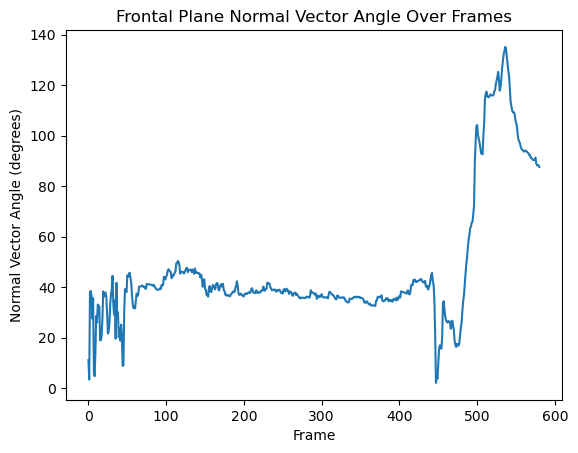

In [12]:
# Get a list with all the frames 
frames_list = list(data.items())[4][1]
normal_vector_angle_list = []
old_angle = 180
unmarked_frames = []
for frame in frames_list:
    if not frame['landmarks']:
        unmarked_frames.append(frame)
        p1, p2, p3 = None, None, None
        angle_list.append(old_angle)
        continue
    else:
        left_hip = [a for a in frame['landmarks'] if a['name'] == 'LEFT_HIP']
        left_shoulder = [a for a in frame['landmarks'] if a['name'] == 'LEFT_SHOULDER']
        right_hip = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_HIP']
        right_shoulder = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_SHOULDER']
        normal_vector = frontal_plane_normal_vector(left_hip, right_hip, left_shoulder, right_shoulder)
        angle = normal_vector_angle(normal_vector)
        normal_vector_angle_list.append(angle)
        old_angle = angle

print(f"There is {len(unmarked_frames)} frames with no landmarks in them.", unmarked_frames)
# Plot the angle over frames
plt.plot(normal_vector_angle_list)
plt.xlabel('Frame')
plt.ylabel('Normal Vector Angle (degrees)')
plt.title('Frontal Plane Normal Vector Angle Over Frames')
plt.show()

In [13]:
frames_list

[{'frame': 0, 'landmarks': []},
 {'frame': 1,
  'landmarks': [{'index': 11,
    'name': 'LEFT_SHOULDER',
    'x': 0.11706622689962387,
    'y': -0.4616546630859375,
    'z': 0.03729555010795593,
    'visibility': 0.9994282126426697},
   {'index': 12,
    'name': 'RIGHT_SHOULDER',
    'x': -0.1394786685705185,
    'y': -0.44766372442245483,
    'z': 0.1109730452299118,
    'visibility': 0.9898667335510254},
   {'index': 23,
    'name': 'LEFT_HIP',
    'x': 0.09292369335889816,
    'y': 0.0009170409757643938,
    'z': -0.010153437033295631,
    'visibility': 0.9973864555358887},
   {'index': 24,
    'name': 'RIGHT_HIP',
    'x': -0.09292730689048767,
    'y': -0.0013195829233154655,
    'z': 0.011377266608178616,
    'visibility': 0.9880036115646362},
   {'index': 25,
    'name': 'LEFT_KNEE',
    'x': 0.06862355023622513,
    'y': 0.3851394057273865,
    'z': -0.07585997879505157,
    'visibility': 0.9287341833114624},
   {'index': 26,
    'name': 'RIGHT_KNEE',
    'x': -0.06831783056259

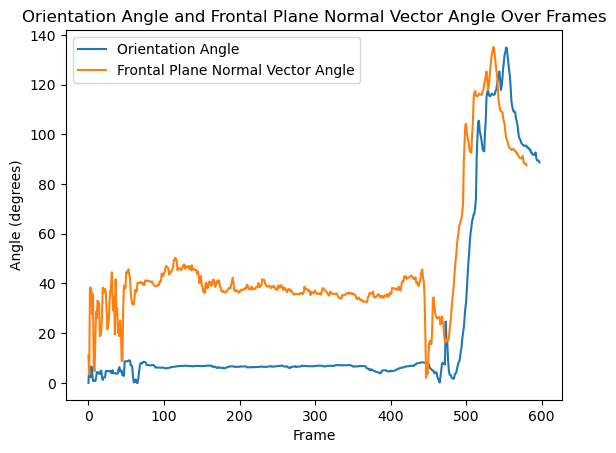

In [14]:
# Plot side to side the orientation angle and the frontal plane normal vector angle
plt.plot(orientation_list, label='Orientation Angle')
plt.plot(normal_vector_angle_list, label='Frontal Plane Normal Vector Angle')
plt.xlabel('Frame')
plt.ylabel('Angle (degrees)')
plt.title('Orientation Angle and Frontal Plane Normal Vector Angle Over Frames')
plt.legend()
plt.show()

# Projecting Femur and Tibia onto the normal plane

In [15]:
def projection_onto_the_frontal_plane(v1, v2, n):
    v1_proj = n - np.dot(v1, n) * v1
    v2_proj = n - np.dot(v2, n) * v2
    return v1_proj, v2_proj

In [16]:
def angle_between_vectors(v1, v2):
    cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle = np.arccos(cosine_angle)
    if np.cross(v1, v2)[2] > 0:  # Check the sign of the angle using the cross product
        angle = -angle
    return np.degrees(angle)

There is 17 frames with no landmarks in them. [{'frame': 0, 'landmarks': []}, {'frame': 2, 'landmarks': []}, {'frame': 9, 'landmarks': []}, {'frame': 21, 'landmarks': []}, {'frame': 22, 'landmarks': []}, {'frame': 31, 'landmarks': []}, {'frame': 34, 'landmarks': []}, {'frame': 35, 'landmarks': []}, {'frame': 38, 'landmarks': []}, {'frame': 43, 'landmarks': []}, {'frame': 46, 'landmarks': []}, {'frame': 49, 'landmarks': []}, {'frame': 50, 'landmarks': []}, {'frame': 51, 'landmarks': []}, {'frame': 52, 'landmarks': []}, {'frame': 54, 'landmarks': []}, {'frame': 55, 'landmarks': []}]


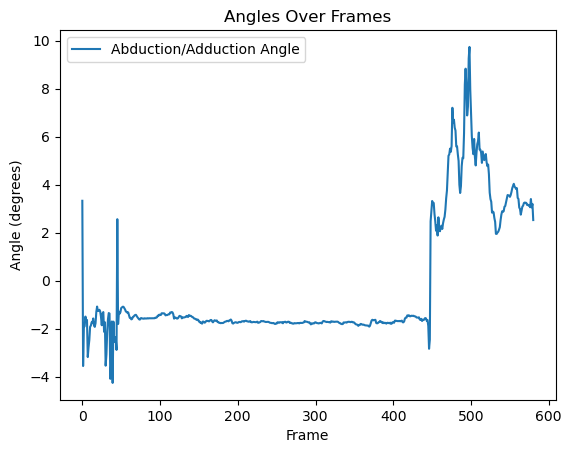

In [17]:
# Get a list with all the frames 
frames_list = list(data.items())[4][1]
normal_vector_angle_list = []
abduction_adduction_angle_list = []
old_angle = 180
unmarked_frames = []
for frame in frames_list:
    if not frame['landmarks']:
        unmarked_frames.append(frame)
        p1, p2, p3 = None, None, None
        angle_list.append(old_angle)
        continue
    else:
        left_hip = [a for a in frame['landmarks'] if a['name'] == 'LEFT_HIP']
        left_shoulder = [a for a in frame['landmarks'] if a['name'] == 'LEFT_SHOULDER']
        right_hip = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_HIP']
        right_shoulder = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_SHOULDER']
        left_knee = [a for a in frame['landmarks'] if a['name'] == 'LEFT_KNEE']
        left_ankle = [a for a in frame['landmarks'] if a['name'] == 'LEFT_ANKLE']
        normal_vector = frontal_plane_normal_vector(left_hip, right_hip, left_shoulder, right_shoulder)
        angle = normal_vector_angle(normal_vector)
        femur = np.array([left_knee[0]['x'] - left_hip[0]['x'], left_knee[0]['y'] - left_hip[0]['y'], left_knee[0]['z'] - left_hip[0]['z']])
        tibia = np.array([left_ankle[0]['x'] - left_knee[0]['x'], left_ankle[0]['y'] - left_knee[0]['y'], left_ankle[0]['z'] - left_knee[0]['z']])
        femur_proj, tibia_proj = projection_onto_the_frontal_plane(femur, tibia, normal_vector)
        abduction_adduction_angle = angle_between_vectors(femur_proj, tibia_proj)
        normal_vector_angle_list.append(angle)
        abduction_adduction_angle_list.append(abduction_adduction_angle)
        old_angle = angle

print(f"There is {len(unmarked_frames)} frames with no landmarks in them.", unmarked_frames)
# Plot the angle over frames
# plt.plot(normal_vector_angle_list, label='Frontal Plane Normal Vector Angle')
plt.plot(abduction_adduction_angle_list, label='Abduction/Adduction Angle')
plt.xlabel('Frame')
plt.ylabel('Angle (degrees)')
plt.title('Angles Over Frames')
plt.legend()
plt.show()

In [18]:
np.atan2(tibia, femur)

array([ 1.67020549,  0.67405735, -1.99663742])

# -----------------------------------------------------------------------

In [19]:
# Synchronized video (top) + knee-angle plot (bottom) animation
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


video_path = 'test_annoted.avi'
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 30
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame)
cap.release()

# Ensure `angle_list` exists (computed earlier) and synchronize lengths
try:
    n_frames = min(len(frames), len(abduction_adduction_angle_list))
except NameError:
    raise NameError('abduction_adduction_angle_list not found. Run the cell that computes abduction and adduction angles first.')
if n_frames == 0:
    raise RuntimeError('No frames or abduction/adduction angles available to animate.')
frames = frames[:n_frames]
angles = np.array(abduction_adduction_angle_list[:n_frames])
# vectors = np.array(orientation_list[:n_frames])

# Create figure with video on top and plot below
fig = plt.figure(figsize=(8,8))
ax_vid = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax_plot = plt.subplot2grid((3,1),(2,0))
im = ax_vid.imshow(frames[0])
ax_vid.axis('off')
# Plot full angle trace and set up vertical frame indicator
ax_plot.plot(np.arange(n_frames), angles, color='C0')
# ax_plot.plot(np.arange(n_frames), vectors, color='C1')
vline = ax_plot.axvline(0, color='r', linewidth=2)
ax_plot.set_xlim(0, n_frames-1)
pad = max(5, (angles.max()-angles.min())*0.05)
ax_plot.set_ylim(angles.min()-pad, angles.max()+pad)
ax_plot.set_xlabel('Frame')
ax_plot.set_ylabel('Abduction/Adduction Angle (degrees)')
plt.tight_layout()

# Init function: display first frame and set vertical line to 0
# def init():
#     im.set_data(frames[0])
#     vline.set_xdata(0)
#     return im, vline

# Update function: swap video frame and move vertical line
def update(i, frames, im, vline):
    im.set_data(frames[i])
    vline.set_xdata([i,i])
    return im, vline

interval = 1000.0 / (fps if fps>0 else 30)
ani = animation.FuncAnimation(fig, update, frames=n_frames, fargs=(frames, im, vline), blit=False, interval=interval)
# Display as JS animation inline in the notebook
ani.save('abduction_adduction.gif', writer='ffmpeg')

KeyboardInterrupt: 

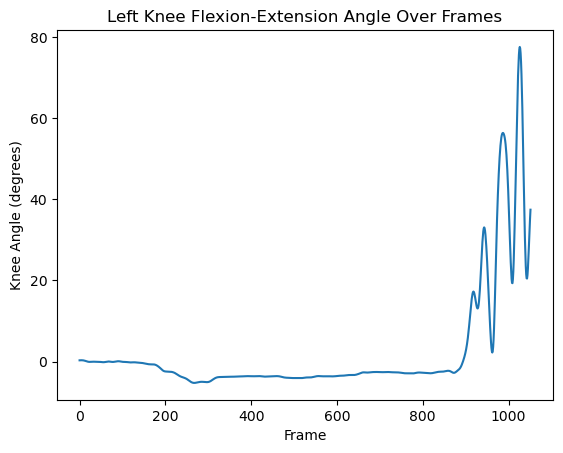

In [1]:
# from the ATH01_S1_PreCut03.csv file, get the left knee abduction-adduction angle over frames and plot it.

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('ATH01_S1_PreCUT03.csv')
angles = df['LKNE_Flexion_Extension']  # Replace with the actual column name for the left knee angle

plt.plot(angles)
plt.xlabel('Frame')
plt.ylabel('Knee Angle (degrees)')
plt.title('Left Knee Flexion-Extension Angle Over Frames')
plt.show()

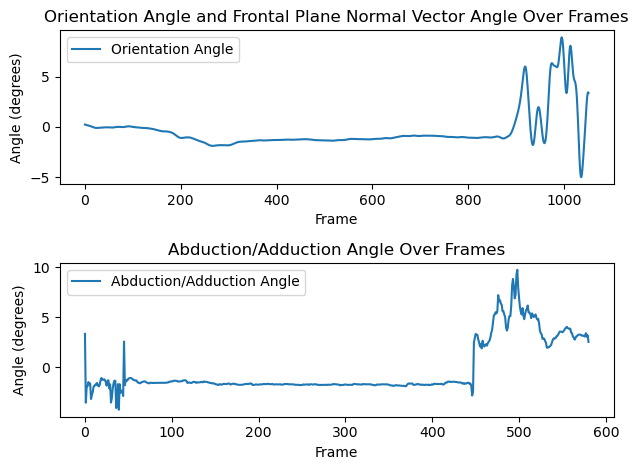

<Figure size 640x480 with 0 Axes>

In [21]:
# PLot next to each other the abduction-adduction angle and the angles from the csv file over frames.
plt.subplot(2, 1, 1)
plt.plot(df['LKNE_Abduction_Adduction'], label='Orientation Angle')
plt.xlabel('Frame')
plt.ylabel('Angle (degrees)')
plt.title('Orientation Angle and Frontal Plane Normal Vector Angle Over Frames')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(abduction_adduction_angle_list, label='Abduction/Adduction Angle')
plt.xlabel('Frame')
plt.ylabel('Angle (degrees)')
plt.title('Abduction/Adduction Angle Over Frames')
plt.legend()
plt.tight_layout()
plt.show()
# Save the plot as a png file
plt.savefig('angles_comparison.png')

In [62]:
print(f"Max abduction/adduction angle: {max(abduction_adduction_angle_list)}")
print(f"Max ground truth angle: {max(df['LKNE_Abduction_Adduction'])}")
print(f"Min abduction/adduction angle: {min(abduction_adduction_angle_list)}")
print(f"Min ground truth angle: {min(df['LKNE_Abduction_Adduction'])}")

Max abduction/adduction angle: 9.738444934217533
Max ground truth angle: 8.916638311568255
Min abduction/adduction angle: -4.25743217118383
Min ground truth angle: -5.003753187179302


In [79]:
import json, os, pathlib, cv2, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


def angle_between_points(p1, p2, p3):
    a = np.array(p1)
    b = np.array(p2)
    c = np.array(p3)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.arccos(cosine_angle)

    return np.degrees(angle)


def angle_between_vectors(v1, v2):
    cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle = np.arccos(cosine_angle)
    if np.cross(v1, v2)[2] > 0:  # Check the sign of the angle using the cross product
        angle = -angle
    return np.degrees(angle)


def orientation_angle(left_hip, right_hip):
    angle = np.arccos((left_hip[0]['x'] - right_hip[0]['x']) / np.sqrt((left_hip[0]['x'] - right_hip[0]['x'])**2 + (left_hip[0]['z'] - right_hip[0]['z'])**2))
    return np.degrees(angle)


def frontal_plane_normal_vector(left_hip, right_hip, left_shoulder, right_shoulder):
# This computes the normalized frontal plane normal vector using the hip and shoulder landmarks.
# It calculates the mid-point of the hips and shoulders, then creates two vectors from 
# the left hip to the mid-point and from the right hip to the mid-point.
    mid_point = [(left_hip[0]['x'] + right_hip[0]['x'] + left_shoulder[0]['x'] + right_shoulder[0]['x']) / 4, 
                 (left_hip[0]['y'] + right_hip[0]['y'] + left_shoulder[0]['y'] + right_shoulder[0]['y']) / 4, 
                 (left_hip[0]['z'] + right_hip[0]['z'] + left_shoulder[0]['z'] + right_shoulder[0]['z']) / 4]
    v1 = [left_hip[0]['x'] - mid_point[0], left_hip[0]['y'] - mid_point[1], left_hip[0]['z'] - mid_point[2]]
    v2 = [right_hip[0]['x'] - mid_point[0], right_hip[0]['y'] - mid_point[1], right_hip[0]['z'] - mid_point[2]]
    normal_vector = np.cross(v1, v2)
    return normal_vector / np.linalg.norm(normal_vector)


def normal_vector_angle(normal_vector):
    angle = np.arccos(normal_vector[2])  # Assuming the normal vector is normalized
    return np.degrees(angle)


def projection_onto_the_frontal_plane(v1, v2, n):
    v1_proj = n - np.dot(v1, n) * v1
    v2_proj = n - np.dot(v2, n) * v2
    return v1_proj, v2_proj

folder_path = "landmarks_summary/ATH_videos_avi/"
output_folder_path = "popo/"
for ath in os.listdir(folder_path):
    for session in os.listdir(os.path.join(folder_path, ath)):
        session_folder_path = os.path.join(folder_path, ath, session)
        for json_file in os.listdir(session_folder_path):
            json_path = os.path.join(session_folder_path, json_file)
            output_session_folder_path = os.path.join(output_folder_path, ath, session)
            if not os.path.exists(output_session_folder_path):
                os.makedirs(output_session_folder_path)
            output_path = os.path.join(output_session_folder_path, json_file.replace('_annoted_results.json', '_angles.csv'))

            try:
                with open(json_path, 'r') as file:
                    data = json.load(file)
                print(f"Processing {json_path}...")
            except FileNotFoundError:
                print(f"Error: The file {json_path} was not found.")
            
            frames_list = list(data.items())[4][1]
            normal_vector_angle_list = []
            abduction_adduction_angle_list = []
            old_angle = 0
            unmarked_frames = []

            for frame in frames_list:
                if not frame['landmarks']:
                    unmarked_frames.append(frame)
                    abduction_adduction_angle_list.append(old_angle)  # Append the last known angle for unmarked frames
                    continue
                else:
                    left_hip = [a for a in frame['landmarks'] if a['name'] == 'LEFT_HIP']
                    left_shoulder = [a for a in frame['landmarks'] if a['name'] == 'LEFT_SHOULDER']
                    right_hip = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_HIP']
                    right_shoulder = [a for a in frame['landmarks'] if a['name'] == 'RIGHT_SHOULDER']
                    left_knee = [a for a in frame['landmarks'] if a['name'] == 'LEFT_KNEE']
                    left_ankle = [a for a in frame['landmarks'] if a['name'] == 'LEFT_ANKLE']
                    normal_vector = frontal_plane_normal_vector(left_hip, right_hip, left_shoulder, right_shoulder)
                    angle = normal_vector_angle(normal_vector)
                    femur = np.array([left_knee[0]['x'] - left_hip[0]['x'], left_knee[0]['y'] - left_hip[0]['y'], left_knee[0]['z'] - left_hip[0]['z']])
                    tibia = np.array([left_ankle[0]['x'] - left_knee[0]['x'], left_ankle[0]['y'] - left_knee[0]['y'], left_ankle[0]['z'] - left_knee[0]['z']])
                    femur_proj, tibia_proj = projection_onto_the_frontal_plane(femur, tibia, normal_vector)
                    abduction_adduction_angle = angle_between_vectors(femur_proj, tibia_proj)
                    normal_vector_angle_list.append(angle)
                    abduction_adduction_angle_list.append(abduction_adduction_angle)
                    old_angle = abduction_adduction_angle
            
            # Save Abduction/Adduction angles and Normal Vector angles to a CSV file with Headers for frame_id, normal_angle, abduction_angle
            with open(output_path, 'w') as f:
                f.write('frame_id,normal_angle,abduction_angle\n')
                for i in range(len(frames_list)):
                    f.write(f"{frames_list[i]['frame']},{normal_vector_angle_list[i]},{abduction_adduction_angle_list[i]}\n")
            break
        break
    break


Processing landmarks_summary/ATH_videos_avi/ATH18/s2/Pre Cut02.2103582.20240113114243_annoted_results.json...


In [77]:
print(len(normal_vector_angle_list), len(abduction_adduction_angle_list), len(unmarked_frames))

664 664 0


In [18]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2, time, sys, os, pathlib, json, imageio

mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_pose = mp.solutions.pose

custom_style = mp_drawing_styles.get_default_pose_landmarks_style()
custom_connections = list(mp_pose.POSE_CONNECTIONS)
excluded_landmarks = [
    mp_pose.PoseLandmark.LEFT_EYE, 
    mp_pose.PoseLandmark.RIGHT_EYE, 
    mp_pose.PoseLandmark.LEFT_EYE_INNER, 
    mp_pose.PoseLandmark.RIGHT_EYE_INNER, 
    mp_pose.PoseLandmark.LEFT_EAR,
    mp_pose.PoseLandmark.RIGHT_EAR,
    mp_pose.PoseLandmark.LEFT_EYE_OUTER,
    mp_pose.PoseLandmark.RIGHT_EYE_OUTER,
    mp_pose.PoseLandmark.NOSE,
    mp_pose.PoseLandmark.MOUTH_LEFT,
    mp_pose.PoseLandmark.MOUTH_RIGHT,
    mp_pose.PoseLandmark.RIGHT_ELBOW,
    mp_pose.PoseLandmark.RIGHT_WRIST,
    mp_pose.PoseLandmark.RIGHT_THUMB,
    mp_pose.PoseLandmark.RIGHT_PINKY,
    mp_pose.PoseLandmark.RIGHT_INDEX,
    mp_pose.PoseLandmark.LEFT_ELBOW,
    mp_pose.PoseLandmark.LEFT_WRIST,
    mp_pose.PoseLandmark.LEFT_THUMB,
    mp_pose.PoseLandmark.LEFT_PINKY,
    mp_pose.PoseLandmark.LEFT_INDEX ]
for landmark in excluded_landmarks:
    # we change the way the excluded landmarks are drawn
    custom_style[landmark] = mp_drawing_styles.DrawingSpec(color=(255,255,0), thickness=None) 
    # we remove all connections which contain these landmarks
    custom_connections = [connection_tuple for connection_tuple in custom_connections if landmark.value not in connection_tuple]

pose =  mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

def pose_estimation_from_folder(folder_path, output_folder_path):
    for ath in os.listdir(folder_path):
        for session in os.listdir(os.path.join(folder_path, ath)):
            session_folder_path = os.path.join(folder_path, ath, session)
            for video_name in os.listdir(session_folder_path):
                frames_list = []
                video_path = os.path.join(session_folder_path, video_name)
                output_session_folder_path = os.path.join(output_folder_path, ath, session)
                output_path = os.path.join(output_session_folder_path, pathlib.Path(video_name).stem + "_annoted.mp4")

                if pathlib.Path(output_path).exists():
                    print(f"Output {output_path} already exists. Skipping.")
                    continue

                cv2.startWindowThread()
                cap = cv2.VideoCapture(video_path)

                avg_fps = []

                width, height, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))
                video_writer = cv2.VideoWriter(output_path, fourcc=cv2.VideoWriter_fourcc(*"MJPG"), fps=float(fps), frameSize=(width, height))

                os.makedirs(os.path.dirname(output_path), exist_ok=True)

                landmark_summary = "landmarks_summary/" + folder_path + '/' + ath + "/"  + session + "/" + pathlib.Path(output_path).stem + "_results.json"           
                os.makedirs(os.path.dirname(landmark_summary), exist_ok=True)
                frames_landmarks = []
                frame_idx = 0
                
                print(f"Processing {video_path} with output {output_path}")

                while cap.isOpened():
                    ret, frame = cap.read()
                    if not ret:
                        break
                    frame = cv2.resize(frame, (width, height))

                    start_time = time.time()
                    rbg_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    results = pose.process(rbg_frame)
                    process_time = time.time() - start_time

                    mp_drawing.draw_landmarks(frame, results.pose_landmarks, connections=custom_connections, landmark_drawing_spec=custom_style)

                    # Collect landmarks (x, y, z, visibility) for this frame in a serializable form
                    landmarks_data = []
                    # Try common attributes that store landmarks
                    pose_landmarks = getattr(results, 'pose_world_landmarks', None)
                    if pose_landmarks is None:
                        pose_landmarks = getattr(results, 'pose_world_landmarks', None)
                    # Some result variants may store landmarks under different attributes
                    if pose_landmarks is None and hasattr(results, 'pose_results'):
                        pose_landmarks = getattr(results.pose_results, 'landmark', None)

                    if pose_landmarks is not None:
                        landmark_list = getattr(pose_landmarks, 'landmark', None) or pose_landmarks
                        if landmark_list:
                            for idx, lm in enumerate(landmark_list):
                                try:
                                    name = mp_pose.PoseLandmark(idx).name
                                    if mp_pose.PoseLandmark(idx) in excluded_landmarks:
                                        continue
                                except Exception:
                                    name = str(idx)
                                visibility = getattr(lm, 'visibility', None)
                                landmarks_data.append({
                                    'index': idx,
                                    'name': name,
                                    'x': float(lm.x),
                                    'y': float(lm.y),
                                    'z': float(lm.z),
                                    'visibility': float(visibility) if visibility is not None else None
                                })

                    frames_landmarks.append({'frame': frame_idx, 'landmarks': landmarks_data})
                    frame_idx += 1
                    
                    fps = 1 / process_time if process_time > 0 else 0
                    avg_fps.append(fps)
                    fps = sum(avg_fps) / len(avg_fps)
                    frames_list.append(frame)
                    video_writer.write(frame)
                    cv2.imshow(str(), frame)
                    
                    if cv2.waitKey(1) & 0xFF == ord("q"):
                        break

                # Write collected landmarks to JSON
                summary = {
                    'athlete': ath,
                    'session': session,
                    'video': os.path.basename(video_path),
                    'frame_count': frame_idx,
                    'frames': frames_landmarks
                }
                with open(landmark_summary, 'w') as fh:
                    json.dump(summary, fh, indent=2)

                print(f"Wrote summary to {landmark_summary}. Processed {frame_idx} frames.")


                video_writer.release()
                cap.release()

                cv2.destroyAllWindows()
                for i in range (1,5):
                    cv2.waitKey(1)


I0000 00:00:1775801628.265536   24308 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-18.8.16), renderer: Intel(R) HD Graphics 6000


W0000 00:00:1775801628.774158  247831 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775801628.888374  247832 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [21]:
pose_estimation_from_folder("ATH_videos_avi", "ATH_videos_avi_processed")

Output ATH_videos_avi_processed/ATH18/s2/Pre Cut03.2103582.20240113111650_annoted.mp4 already exists. Skipping.
Output ATH_videos_avi_processed/ATH18/s2/Pre Cut.2103582.20240113111621_annoted.mp4 already exists. Skipping.
Output ATH_videos_avi_processed/ATH18/s2/Pre Cut04.2103582.20240113111701_annoted.mp4 already exists. Skipping.
Output ATH_videos_avi_processed/ATH18/s2/Pre Cut05.2103582.20240113111710_annoted.mp4 already exists. Skipping.
Output ATH_videos_avi_processed/ATH18/s2/Pre Cut02.2103582.20240113114243_annoted.mp4 already exists. Skipping.
Output ATH_videos_avi_processed/ATH18/s2/Pre Cut01.2103582.20240113111633_annoted.mp4 already exists. Skipping.
Output ATH_videos_avi_processed/ATH18/s1/Pre Cut.2103582.20240113111135_annoted.mp4 already exists. Skipping.
Output ATH_videos_avi_processed/ATH18/s1/Pre Cut05.2103582.20240113111419_annoted.mp4 already exists. Skipping.
Output ATH_videos_avi_processed/ATH18/s1/Pre Cut02.2103582.20240113111154_annoted.mp4 already exists. Skippi

In [25]:
import pandas as pd
pd.read_csv('knee_angle_csv/ATH_videos_avi/ATH01/s1/Pre Cut03.2103582.20240108160826_angles.csv')

,frame_id,normal_angle,left_abduction_angle,right_abduction_angle
0,0,0.000000,0.000000,0.000000
1,1,11.066474,3.329304,1.804425
2,2,11.066474,3.329304,1.804425
3,3,3.370075,-3.553595,-1.232215
4,4,37.972139,-1.925841,-0.511088
...,...,...,...,...
593,593,88.957586,3.059755,0.633783
594,594,88.175158,3.402200,0.505387
595,595,88.241307,3.052964,0.530604
596,596,88.255493,3.198131,0.499831


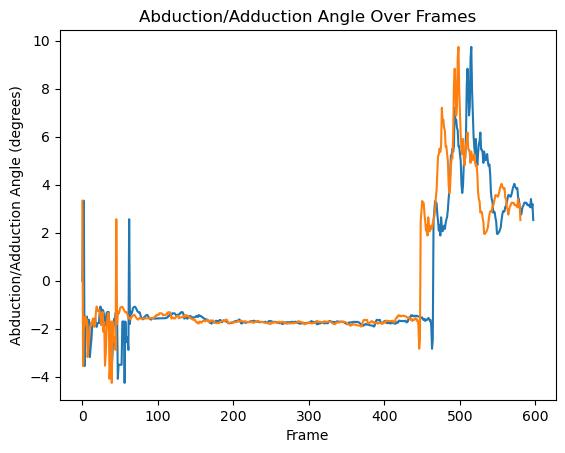

In [28]:
# Plot the abduction-adduction angle over frames
import matplotlib.pyplot as plt
angles_df = pd.read_csv('knee_angle_csv/ATH_videos_avi/ATH01/s1/Pre Cut03.2103582.20240108160826_angles.csv')
plt.plot(angles_df['left_abduction_angle'])
plt.plot(abduction_adduction_angle_list, label='Abduction/Adduction Angle')
plt.xlabel('Frame')
plt.ylabel('Abduction/Adduction Angle (degrees)')
plt.title('Abduction/Adduction Angle Over Frames')
plt.show()

In [32]:
print(len(angles_df['left_abduction_angle']), len(abduction_adduction_angle_list), len(df['LKNE_Abduction_Adduction']))


598 581 1052


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

input_folder = "knee_angle_csv/ATH_videos_avi/"
output_folder = "Angle_plots/"
for ath in os.listdir(input_folder):
    for session in os.listdir(os.path.join(input_folder, ath)):
        session_folder_path = os.path.join(input_folder, ath, session)
        # Make a subplot that will plot all 6 csv files in the session folder
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'Abduction/Adduction Angle Over Frames for {ath} {session}')
        axes = axes.flatten()
        i = 0
        for csv_file in sorted(os.listdir(session_folder_path)):
            csv_path = os.path.join(session_folder_path, csv_file)
            df = pd.read_csv(csv_path)
            axes[i].plot(df['abduction_angle'], label='Abduction/Adduction Angle')
            axes[i].set_xlabel('Frame')
            axes[i].set_ylabel('Abduction/Adduction Angle (degrees)')
            # axes[i].set_title(f'Abduction/Adduction Angle Over Frames for {ath} {session}')
            axes[i].set_title(f'{csv_file}')
            axes[i].legend()
            i += 1
        plt.tight_layout()
        if not os.path.exists(f'{output_folder}/{ath}'):
            os.makedirs(f'{output_folder}/{ath}')
        plt.savefig(f'{output_folder}/{ath}/{session}_abduction_adduction_angles.png')

: 